**Nombre:** Pablo Alejandro Aguirre Higuera

**Matrícula:** 263845

**Maestría en Inteligencia Artificial y Analítica de Datos**

**Fecha:** 26/10/2025

### **Instrucciones y Objetivos para la Práctica: Regresión Lasso y Ridge**

#### **📌 Objetivos de la Práctica:**  
Al finalizar esta práctica, los estudiantes serán capaces de:  
1. **Realizar un Análisis Exploratorio de Datos (EDA)** completo, incluyendo visualización de distribuciones, detección de outliers y análisis de correlaciones.  
2. **Preprocesar datos** correctamente, manejando valores faltantes, codificando variables categóricas y escalando características.  
3. **Implementar modelos de regresión Lasso y Ridge**, entendiendo cómo la regularización afecta los coeficientes.  
4. **Verificar los supuestos de la regresión lineal** (linealidad, normalidad de residuos, homocedasticidad y multicolinealidad).  
5. **Comparar el rendimiento** de ambos modelos y analizar qué variables son más relevantes en cada caso.  

---

### **📋 Instrucciones**  

#### **🔹 Paso 1: Configuración Inicial**
✅ Carga el set de datos que puedes encontrar en el campus virtual
✅ Ejecutar las celdas de importación de librerías y carga del dataset.  
✅ Familiarizarse con los datos usando `.head()`, `.info()` y `.describe()`.  

#### **🔹 Paso 2: Análisis Exploratorio (EDA)**  
📊 **Para variables numéricas:**  
- Generar histogramas y boxplots para identificar distribuciones y outliers.  
- Calcular medidas de tendencia central y dispersión.  

📊 **Para variables categóricas:**  
- Usar gráficos de barras para visualizar frecuencias.    

#### **🔹 Paso 3: Matriz de Correlación**  
✅ Calcular la matriz de correlación **solo para variables numéricas**.  
✅ Generar un **mapa de calor** para visualizar relaciones.  
📌 **Pregunta:** ¿Qué variables están más correlacionadas con el target (`charges`)? (salida del dataset)  

#### **🔹 Paso 4: Preprocesamiento**  
🔧 **Tareas:**  
1. Manejar valores faltantes con `SimpleImputer`.  
2. Codificar variables categóricas con `OneHotEncoder`.  
3. Estandarizar variables numéricas con `StandardScaler`.  
✅ Verificar que el dataset transformado no tenga valores nulos.  

#### **🔹 Paso 5: Modelado (Lasso y Ridge)**  
🎯 **Para cada modelo:**  
1. Ajustar el modelo con los hiperparámetros dados (`alpha=0.1` para Lasso, `alpha=1.0` para Ridge).  
2. Calcular **MSE** y **R²** para evaluar rendimiento.  
3. Analizar los coeficientes para identificar variables importantes.  

📌 **Pregunta:**  
- ¿Qué modelo tiene un mejor R²? ¿Por qué crees que ocurre esto?  
- ¿Qué variables tienen coeficientes cercanos a cero en Lasso? ¿Por qué?  

#### **🔹 Paso 6: Verificación de Supuestos**  
📉 **Para cada modelo, verificar:**  
1. **Linealidad** (gráfico de residuos vs predicciones).  
2. **Normalidad de residuos** (QQ-Plot y test de Shapiro-Wilk).  
3. **Homocedasticidad**
4. **Multicolinealidad** (VIF > 10 indica problema).  

📌 **Pregunta:**  
- ¿Se cumplen los supuestos en ambos modelos?  
- Si hay heterocedasticidad, ¿cómo podría solucionarse?  

#### **🔹 Paso 7: Comparación Final**  
📊 **Analizar:**  
- ¿Qué modelo es más interpretable?  
- ¿Cuál reduce mejor el sobreajuste?  
- ¿Qué variables son más importantes en cada caso?  

---

### **📌 Entrega de la Práctica**  
Al finalizar la practica, incluye un texto con los siguientes elementos
- Incluir **comentarios explicativos** en cada paso.  
- Responder las **preguntas planteadas** en celdas Markdown.  

🎯 **Criterios de Evaluación:**  
✔ **Correcto preprocesamiento** (manejo de nulos, escalado, encoding).  
✔ **Análisis visual y estadístico** (gráficos claros, interpretación de resultados).  
✔ **Validación de supuestos** (justificación de si se cumplen o no).  
✔ **Comparación crítica** entre Lasso y Ridge.  

**1. Configuración Inicial**

In [94]:
import pandas as pd

df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [96]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Se tiene un conjunto de datos de hombres y mujeres con una media de 39 años. Se incluye su índice de masa corporal (bmi), si fuman o no, la región donde habitan y los cargos que tienen. El objetivo es encontrar las variables que mejor predigan los cargos que alguien tiene.

**2. Análisis Exploratorio**

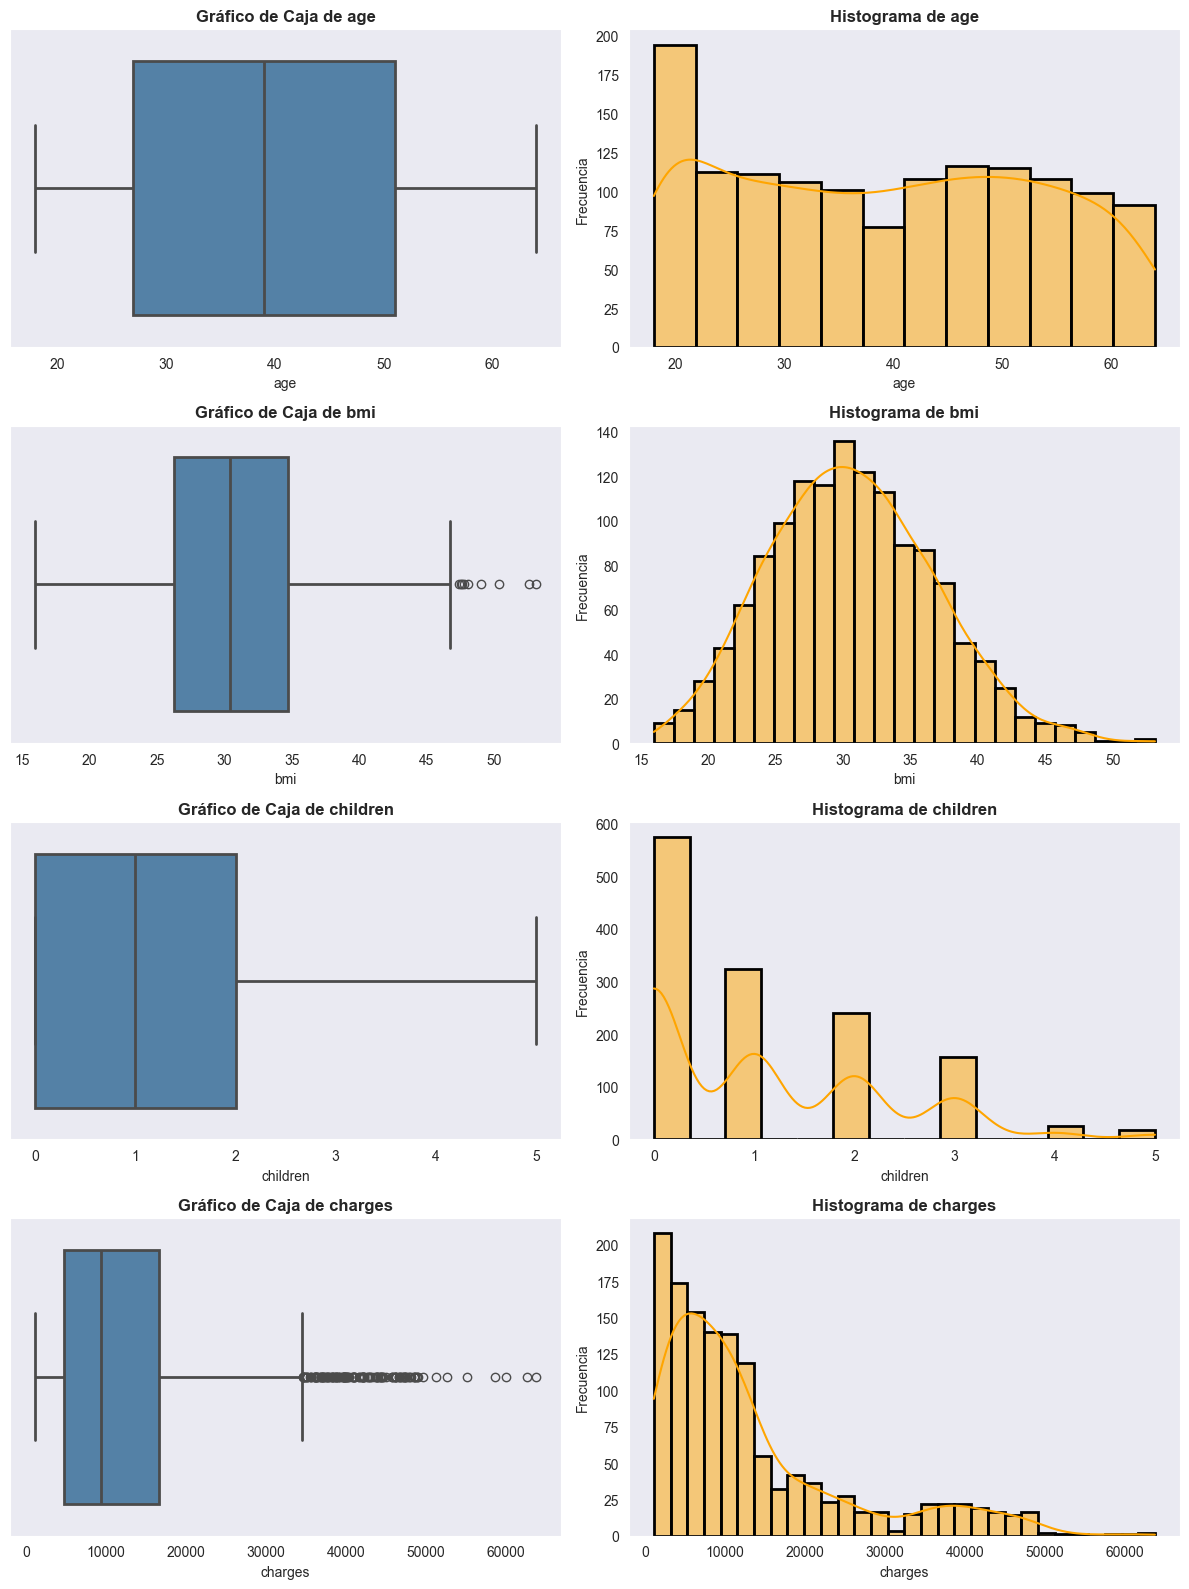

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=['float64', 'int64']).columns
fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 16))
sns.set_style("dark")

for i, col in enumerate(num_cols):

    sns.boxplot(x=df[col], ax=axes[i, 0], color="steelblue", linewidth=2)
    axes[i, 0].set_title(f"Gráfico de Caja de {col}", fontweight="bold")

    sns.histplot(df[col], kde=True, ax=axes[i, 1], color="orange", linewidth=2, edgecolor="black")
    axes[i, 1].set_title(f"Histograma de {col}", fontweight="bold")
    axes[i, 1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

Se puede observar que aunque la edad tiene una distribución centrada y sin valores atípicos, la mayoría las personas tienen cerca de 20 años. El bmi tiene una distribución normal centrada en 30 con un ligero sesgo a la derecha. Al haber más jóvenes cerca de 20 años, no es muy sorprendente que se observe una relación exponencial negativa en el histograma de número de hijos. Los cargos es donde se presentan más valores atípicos con un sesgo a la derecha. 

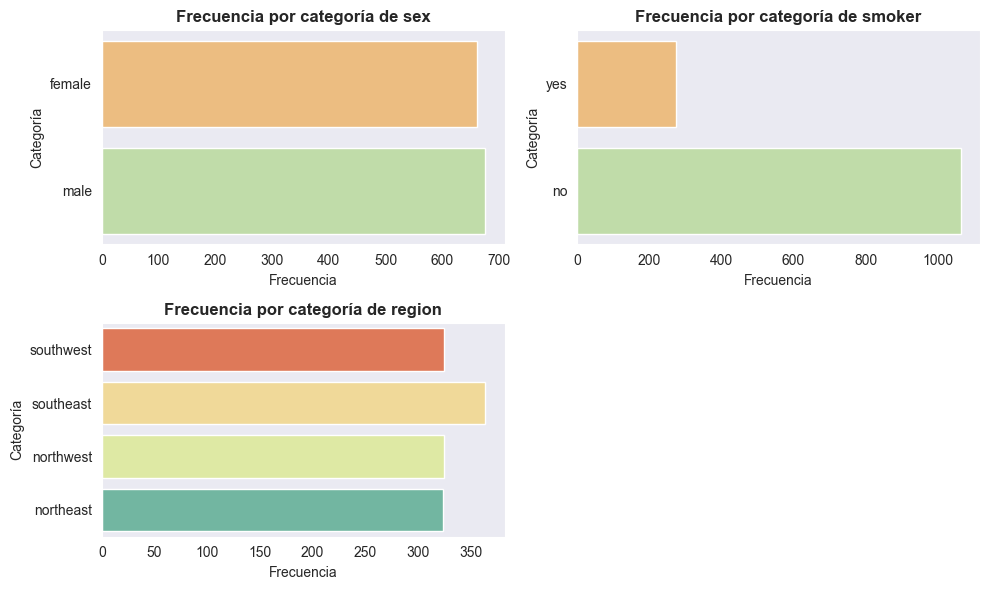

In [98]:
cat_cols = df.select_dtypes(include="object").columns
plt.figure(figsize=(10,6))
for i, col in enumerate(cat_cols, 1):

    plt.subplot(2, 2, i)
    sns.countplot(y=df[col], hue=df[col], palette="Spectral", legend=False)
    plt.title(f"Frecuencia por categoría de {col}", fontweight="bold")
    plt.xlabel("Frecuencia")
    plt.ylabel("Categoría")

plt.tight_layout()
plt.show()

Se tiene casi la misma cantidad de hombres y de mujeres. La gran mayoría son no fumadores. El número de personas de la región southeast supera levemente las frecuencias de las demás regiones.

**3. Matriz de Correlación**

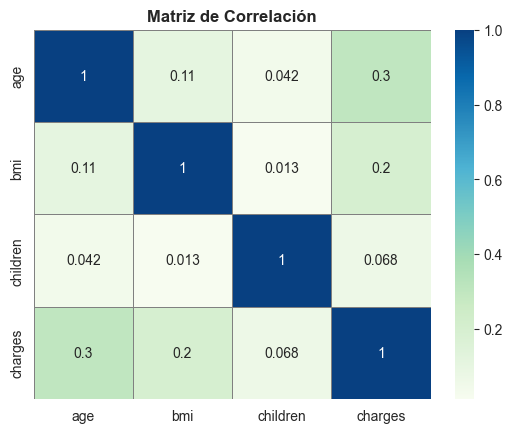

In [99]:
matriz_corr = df[num_cols].corr()

sns.heatmap(matriz_corr, annot=True, cbar=True, cmap="GnBu", linewidths=0.6, linecolor="gray")
plt.title("Matriz de Correlación", fontweight="bold")
plt.show()

Entre las variables numéricas, ninguna tiene una correlación fuerte con charges. La edad es la que mejor correlación tiene con charges, pero apenas con un índice de 0.3.

**4. Preprocesamiento**

No se tienen datos faltanes. Se omite la parte de SimpleImputer.

In [100]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_encoded

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,-1.438764,-0.453320,-0.908614,0.298584,False,True,False,False,True
1,-1.509965,0.509621,-0.078767,-0.953689,True,False,False,True,False
2,-0.797954,0.383307,1.580926,-0.728675,True,False,False,True,False
3,-0.441948,-1.305531,-0.908614,0.719843,True,False,True,False,False
4,-0.513149,-0.292556,-0.908614,-0.776802,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,0.768473,0.050297,1.580926,-0.220551,True,False,True,False,False
1334,-1.509965,0.206139,-0.908614,-0.914002,False,False,False,False,False
1335,-1.509965,1.014878,-0.908614,-0.961596,False,False,False,True,False
1336,-1.296362,-0.797813,-0.908614,-0.930362,False,False,False,False,True


El preprocesamiento se ha llevado a cabo con éxito.

**5. Modelado (Lasso y Ridge)**

In [101]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

lasso = Lasso(alpha=0.1)
X = df_encoded.drop(columns=["charges"])
Y = df_encoded["charges"]

lasso.fit(X, Y)

coef_lasso = pd.DataFrame({"Variable" : X.columns, "Coeficientes" : lasso.coef_})
print("Intercepto:", round(lasso.intercept_,3))
print(coef_lasso)

Y_pred_lasso = lasso.predict(X)

mse = mean_squared_error(Y, Y_pred_lasso)
r2 = r2_score(Y, Y_pred_lasso)

print(f"\nError Cuadrático Medio (MSE): {mse:.3f}")
print(f"Coeficiente de Determinación (R²): {r2:.3f}")

Intercepto: -0.276
           Variable  Coeficientes
0               age      0.204545
1               bmi      0.073949
2          children      0.000000
3          sex_male      0.000000
4        smoker_yes      1.348769
5  region_northwest     -0.000000
6  region_southeast      0.000000
7  region_southwest     -0.000000

Error Cuadrático Medio (MSE): 0.333
Coeficiente de Determinación (R²): 0.667


La regresión Lasso muestra que las variables que tienen influencia alguna sobre charges son: age, bmi y smoker.

In [102]:
from sklearn.linear_model import Ridge

ridge = Ridge()

ridge.fit(X, Y)

coef_ridge = pd.DataFrame({"Variable" : X.columns, "Coeficientes" : ridge.coef_})
print("Intercepto:", round(ridge.intercept_,3))
print(coef_ridge)

Y_pred_ridge = ridge.predict(X)

mse = mean_squared_error(Y, Y_pred_ridge)
r2 = r2_score(Y, Y_pred_ridge)

print(f"\nError Cuadrático Medio (MSE): {mse:.3f}")
print(f"Coeficiente de Determinación (R²): {r2:.3f}")

Intercepto: -0.347
           Variable  Coeficientes
0               age      0.297724
1               bmi      0.170572
2          children      0.047340
3          sex_male     -0.010260
4        smoker_yes      1.960929
5  region_northwest     -0.028733
6  region_southeast     -0.084139
7  region_southwest     -0.078674

Error Cuadrático Medio (MSE): 0.249
Coeficiente de Determinación (R²): 0.751


En la regresión Ridge se concluye que son las mismas variables las que tienen mayor impacto en charges: age, bmi, y smoker. Ridge tiene un mejor desempeño porque, aunque contiene variables que aportan poco o nada a la predicción, sus coeficientes no son iguales a 0 como sucede con Lasso. Lo que Lasso no podrá tener en exactitud, lo tendrá en una mayor interpretabilidad en el modelo.

**6. Verificación de Supuestos**

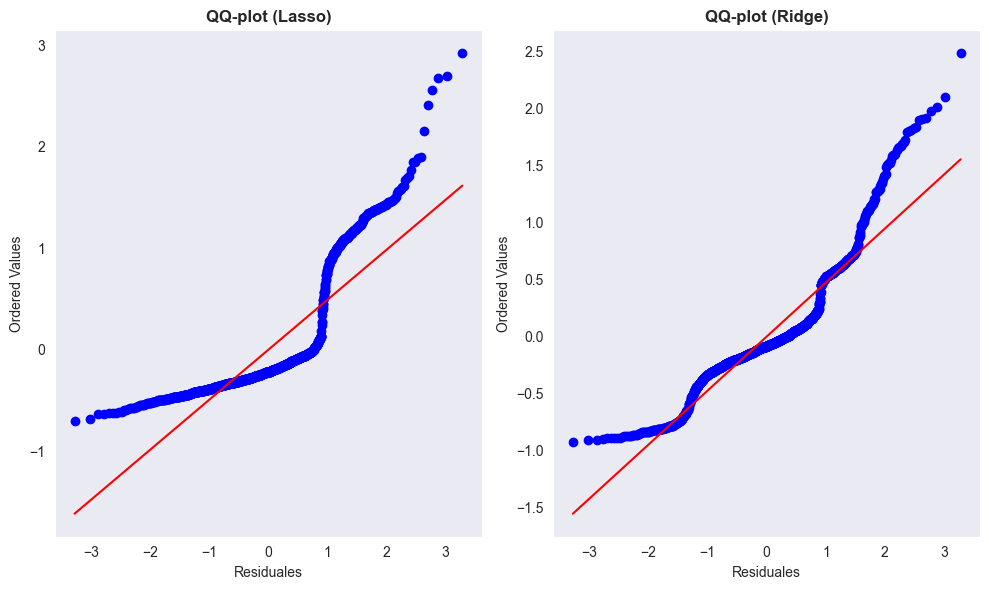

Shapiro-Wilk Test (Lasso): p-valor = 0.00000
Shapiro-Wilk Test (Ridge): p-valor = 0.00000


In [103]:
import scipy.stats as stats

residuos_lasso= Y - Y_pred_lasso
residuos_ridge = Y - Y_pred_ridge

fig, axes = plt.subplots(1, 2, figsize=(10,6))

stats.probplot(residuos_lasso, dist="norm", plot=axes[0])
axes[0].set_title("QQ-plot (Lasso)", fontweight="bold")
axes[0].set_xlabel("Residuales")

stats.probplot(residuos_ridge, dist="norm", plot=axes[1])
axes[1].set_title("QQ-plot (Ridge)", fontweight="bold")
axes[1].set_xlabel("Residuales")

plt.tight_layout()
plt.show()

shapiro_lasso = stats.shapiro(residuos_lasso)
print(f"Shapiro-Wilk Test (Lasso): p-valor = {shapiro_lasso.pvalue:.5f}")

shapiro_ridge = stats.shapiro(residuos_ridge)
print(f"Shapiro-Wilk Test (Ridge): p-valor = {shapiro_ridge.pvalue:.5f}")

Ambos modelos presentan serias desviaciones de la normalidad de residuos - a lo largo de toda la distribución. Ese supuesto no se cumple.

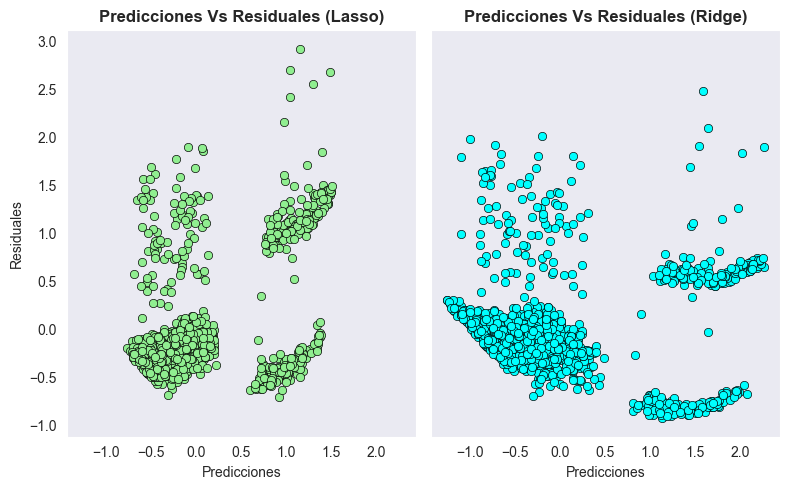

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(8,5), sharex=True, sharey=True)

sns.scatterplot(x=Y_pred_lasso, y=residuos_lasso, color="lightgreen", edgecolor="black", ax=axes[0])
axes[0].set_title("Predicciones Vs Residuales (Lasso)", fontweight="bold")
axes[0].set_xlabel("Predicciones")
axes[0].set_ylabel("Residuales")

sns.scatterplot(x=Y_pred_ridge, y=residuos_ridge, color="cyan", edgecolor="black", ax=axes[1])
axes[1].set_title("Predicciones Vs Residuales (Ridge)", fontweight="bold")
axes[1].set_xlabel("Predicciones")
axes[1].set_ylabel("Residuales")

plt.tight_layout()
plt.show()

En ambas gráficas no se muestra una estructura aleatoria de los puntos. Las diferentes nubes de puntos en cada una de las gráficas muestra que no hay una variación constante de los residuos en el intervalo de las predicciones. Esto sugiere la existencia de otras variables actualmente ausentes en los modelos que explican los cargos. Se concluye que no se cumple con la homocedasticidad.

Para remediar la situación, se sugiere investigar por otras variables que puedan predecir charges y también por posibles interrelaciones entre las variables ya existentes en los modelos.

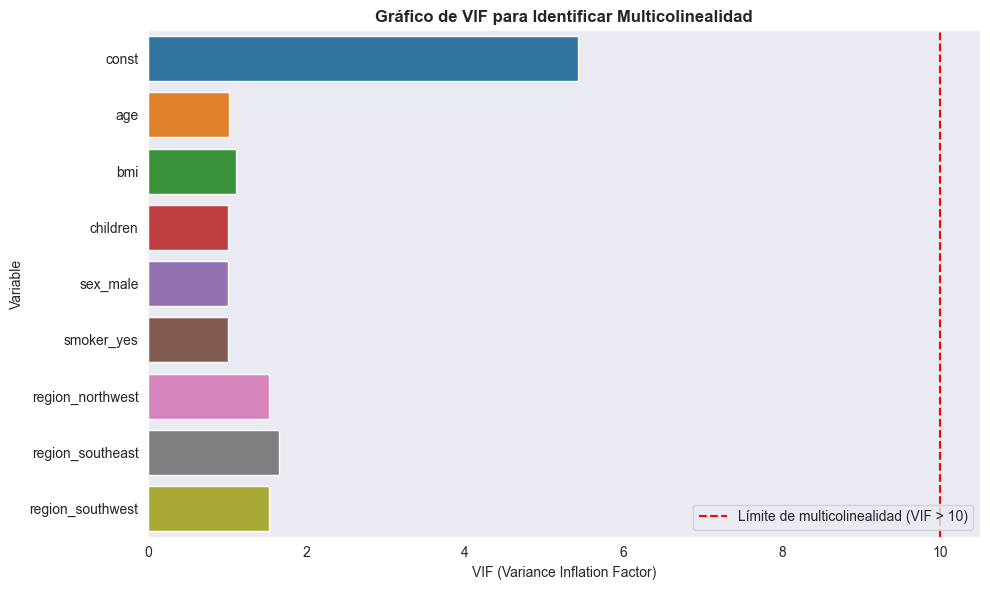

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = add_constant(df_encoded.drop(columns=["charges"]))
bool_cols = X.select_dtypes(include=["bool"]).columns

X[bool_cols] = X[bool_cols].astype(int)

vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

plt.figure(figsize=(10, 6))
sns.barplot(x='VIF', y='Variable', data=vif_data, hue='Variable', legend=False)
plt.axvline(x=10, color='red', linestyle='--', label='Límite de multicolinealidad (VIF > 10)')
plt.xlabel('VIF (Variance Inflation Factor)')

plt.title('Gráfico de VIF para Identificar Multicolinealidad', fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Según el Factor de Inflación de Varianza, no hay problemas serios de multicolinealidad en ambos modelos. El intercepto es el único elemento con una multicolinealidad leve-moderada. Se concluye que se cumple con el supuesto de no multicolinealidad.

**7. Comparación final**

El modelo de Lasso resultó ser el más interpretable ya que las variables irrelevantes quedaron con un coeficiente igual a 0. En ambos modelos quedaron las siguientes variables como las de mayor impacto: age, bmi, y smoker. En este caso, aunque el modelo de Lasso haya tenido un menor porcentaje de la variación, este es el modelo que mejor evita el sobreajuste. Ahora, sería interesante entrenar ambos modelos con una partición en los datos: un conjunto de entrenamiento y otro exclusivamente para prueba. De esta forma, se identificaría cuál de ambos modelos tiene una mejor capacidad de generalización.